In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import stim 
import random
from stim_baconshor import *
import sinter
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [6]:
circuit = bacon_shor_circuit(5,0.6)

In [7]:
circuit

stim.Circuit('''
    QUBIT_COORDS(0, 0, 0) 0
    QUBIT_COORDS(1, 0, 0) 1
    QUBIT_COORDS(2, 0, 0) 2
    QUBIT_COORDS(3, 0, 0) 3
    QUBIT_COORDS(4, 0, 0) 4
    QUBIT_COORDS(0, 1, 0) 5
    QUBIT_COORDS(1, 1, 0) 6
    QUBIT_COORDS(2, 1, 0) 7
    QUBIT_COORDS(3, 1, 0) 8
    QUBIT_COORDS(4, 1, 0) 9
    QUBIT_COORDS(0, 2, 0) 10
    QUBIT_COORDS(1, 2, 0) 11
    QUBIT_COORDS(2, 2, 0) 12
    QUBIT_COORDS(3, 2, 0) 13
    QUBIT_COORDS(4, 2, 0) 14
    QUBIT_COORDS(0, 3, 0) 15
    QUBIT_COORDS(1, 3, 0) 16
    QUBIT_COORDS(2, 3, 0) 17
    QUBIT_COORDS(3, 3, 0) 18
    QUBIT_COORDS(4, 3, 0) 19
    QUBIT_COORDS(0, 4, 0) 20
    QUBIT_COORDS(1, 4, 0) 21
    QUBIT_COORDS(2, 4, 0) 22
    QUBIT_COORDS(3, 4, 0) 23
    QUBIT_COORDS(4, 4, 0) 24
    TICK
    MZZ 0 5 1 6 2 7 3 8 4 9
    TICK
    MZZ 5 10 6 11 7 12 8 13 9 14
    TICK
    MZZ 10 15 11 16 12 17 13 18 14 19
    TICK
    MZZ 15 20 16 21 17 22 18 23 19 24
    TICK
    MXX 0 1 5 6 10 11 15 16 20 21
    TICK
    MXX 1 2 6 7 11 12 16 17 21 22
    TICK


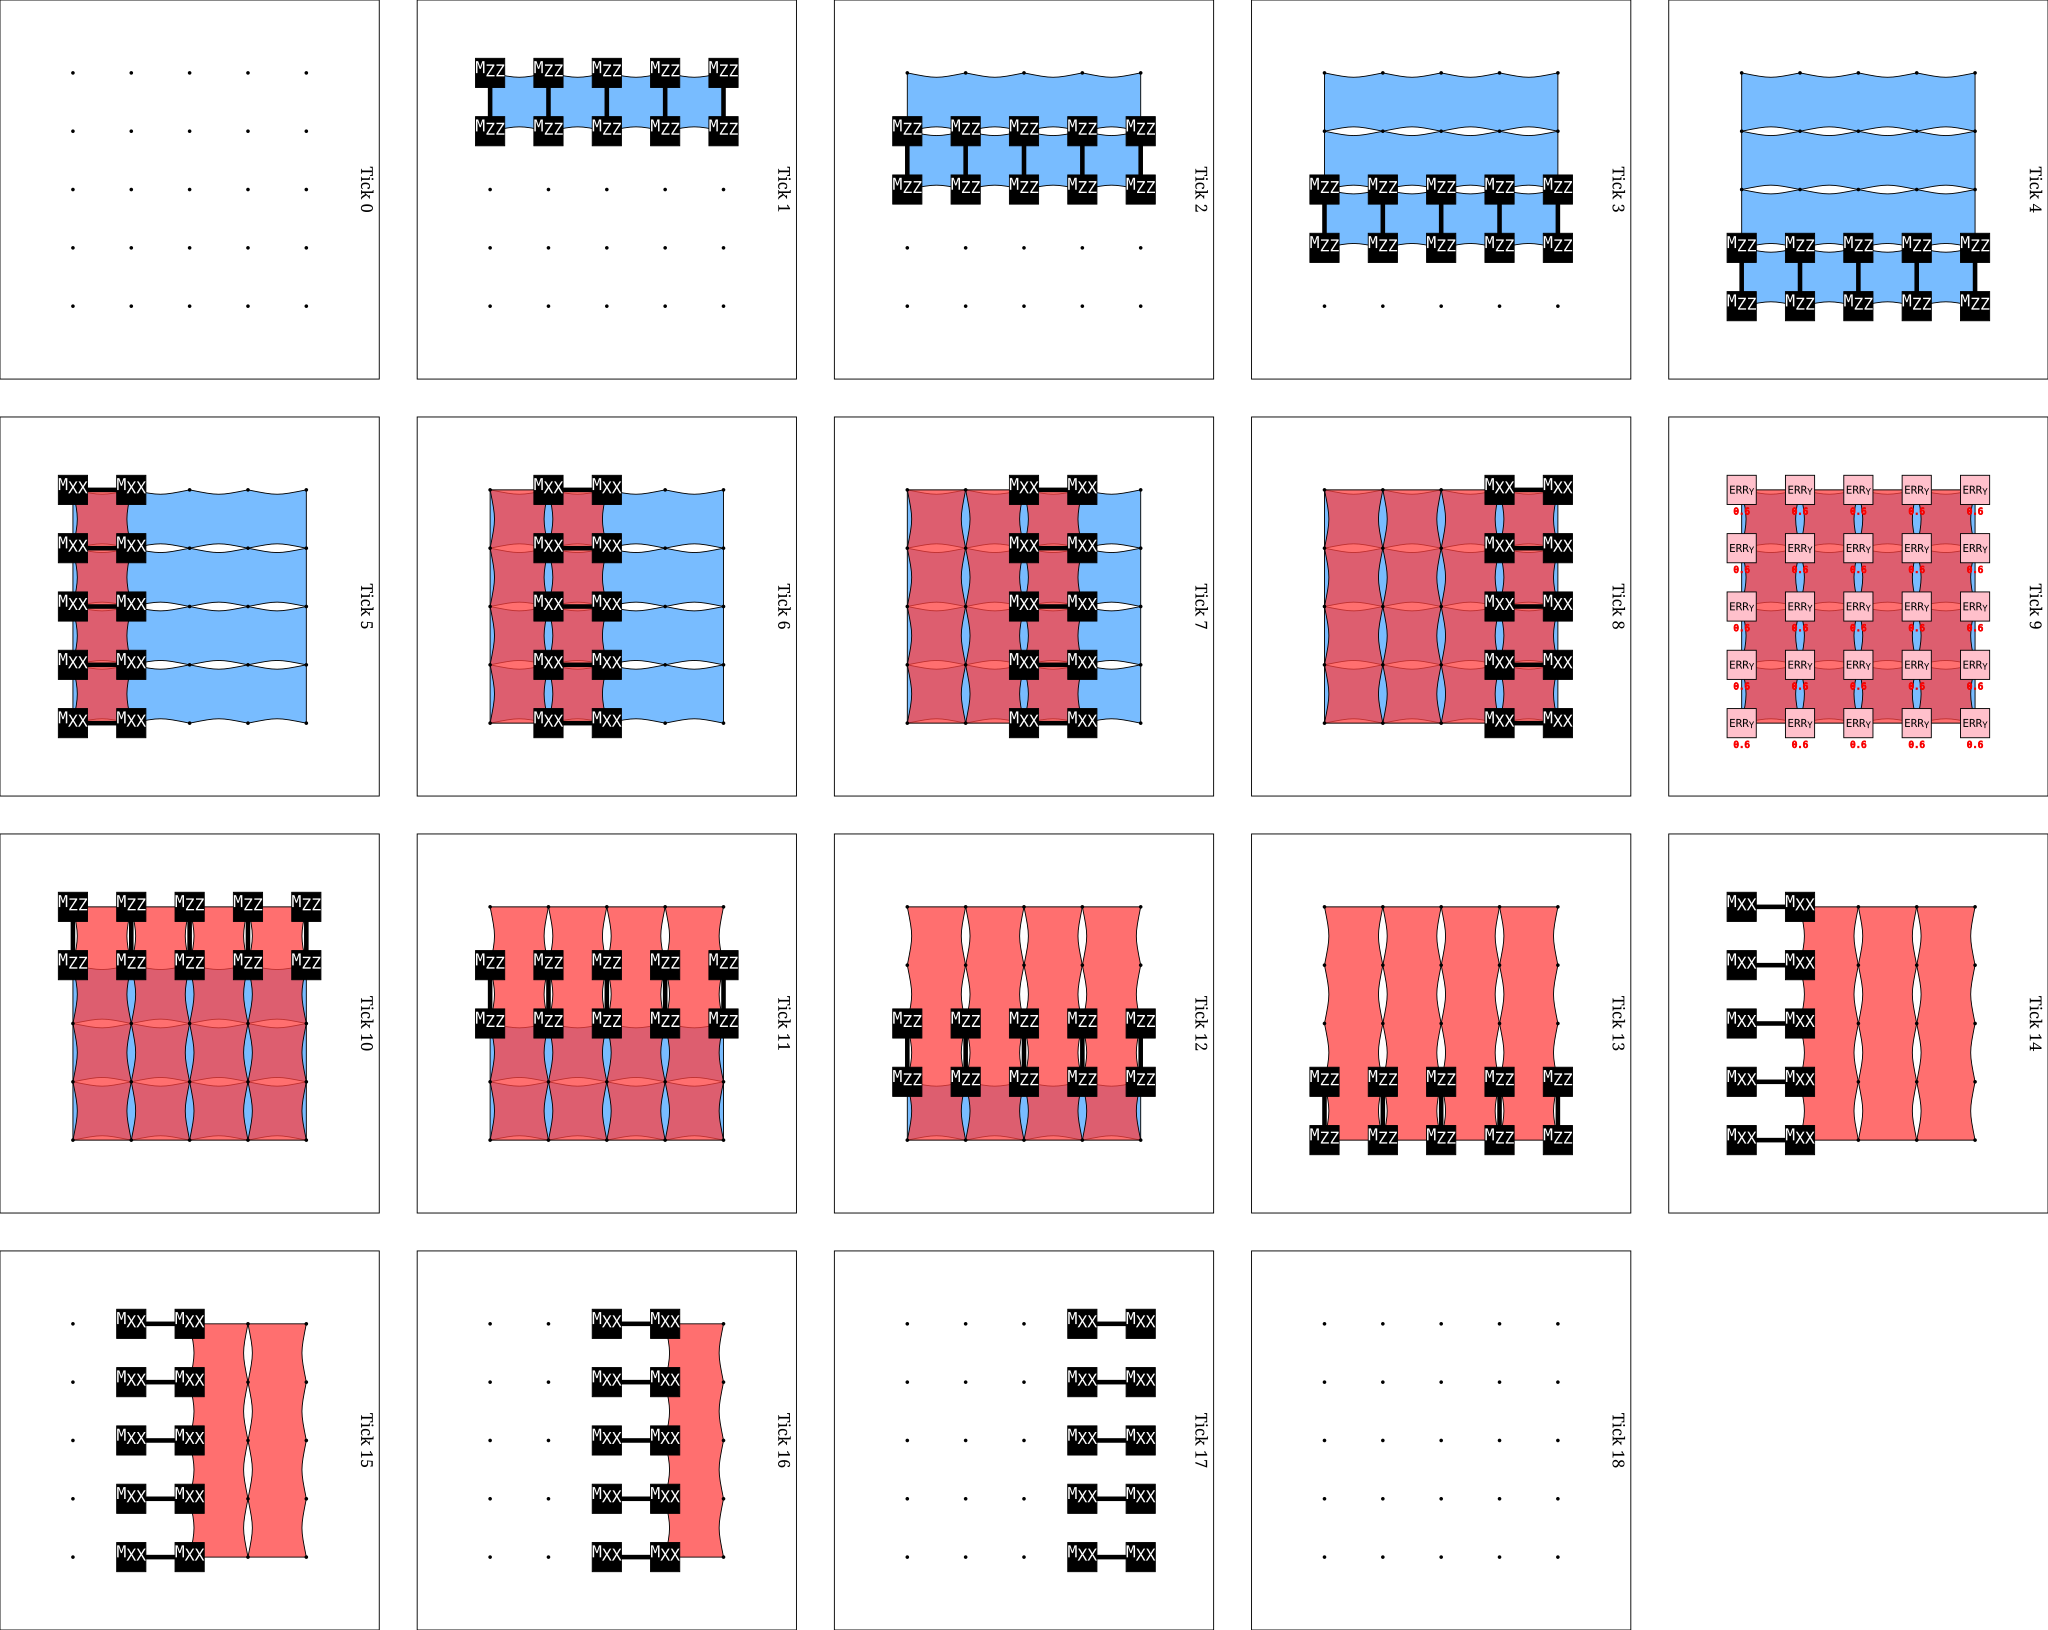

In [8]:
circuit.diagram("detslice-with-ops-svg")

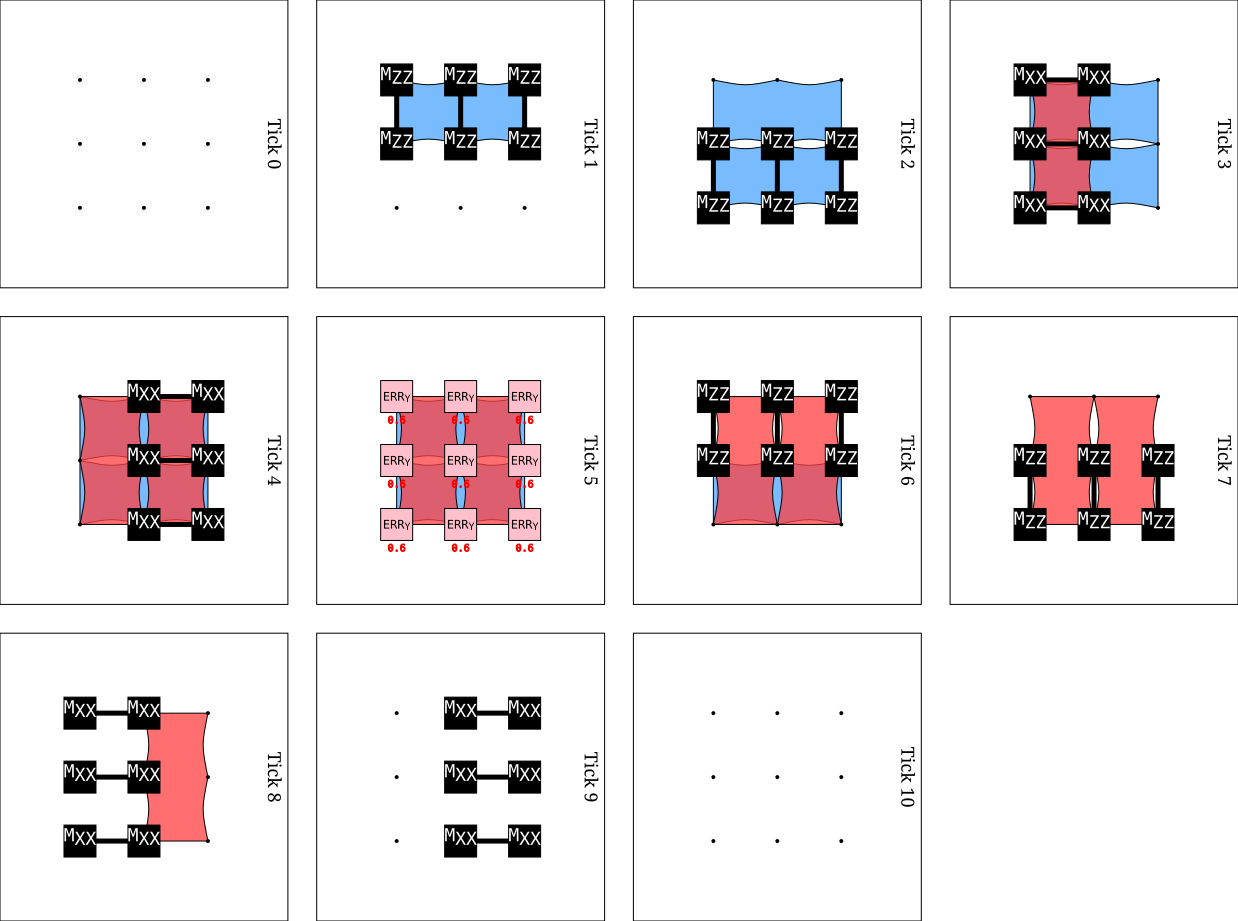

In [5]:
circuit.diagram("detslice-with-ops-svg")

## Only Y error

In [2]:
ps = np.logspace(np.log10(0.001), np.log10(0.04), 50)
tasks = [
    sinter.Task(
        circuit=bacon_shor_circuit(d=7, p=p),
        json_metadata={'p': p, 'd': 7}
    )
    for p in ps
]

# Run the collection
stats = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=100_000,
    max_errors=100,
)

RuntimeError: Worker failed: traceback=Traceback (most recent call last):
  File "/opt/anaconda3/envs/qec_env/lib/python3.11/site-packages/sinter/_collection/_collection_worker_state.py", line 246, in run_message_loop
    did_some_work = self.do_some_work()
                    ^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/qec_env/lib/python3.11/site-packages/sinter/_collection/_collection_worker_state.py", line 217, in do_some_work
    some_work_done = self.compiled_sampler.sample(self.current_task_shots_left)
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/qec_env/lib/python3.11/site-packages/sinter/_collection/_sampler_ramp_throttled.py", line 51, in sample
    result = self.sub_sampler.sample(actual_shots)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/qec_env/lib/python3.11/site-packages/sinter/_decoding/_stim_then_decode_sampler.py", line 193, in sample
    predictions = self.compiled_dec

## High d with y error and small z

p=0.0010781895093053744, errors=101, rate=0.0010926833490203715
p=0.0011624926179761637, errors=100, rate=0.001093984180988743
p=0.00125338734534684, errors=101, rate=0.0010689979995978027
p=0.001, errors=100, rate=0.001004005983875664
p=0.0015709798374755985, errors=100, rate=0.0017355988683895379
p=0.0016938139800964523, errors=103, rate=0.0016690162526534118
p=0.001457053536430442, errors=100, rate=0.0015435671837616732
p=0.001351389086849075, errors=101, rate=0.0012765258275299857
p=0.002289001727854742, errors=106, rate=0.0023925064891095814
p=0.0021230050080244573, errors=100, rate=0.002257081593499605
p=0.0019690462480869506, errors=102, rate=0.002063732928679818
p=0.0018262524640547768, errors=100, rate=0.0017670029862350467
p=0.0030933319548015776, errors=101, rate=0.0034893764035239245
p=0.002660947611165824, errors=103, rate=0.002699090694688294
p=0.0028690057991701875, errors=100, rate=0.002849895978796774
p=0.002467977649754858, errors=102, rate=0.002356692313024191
p=0.00

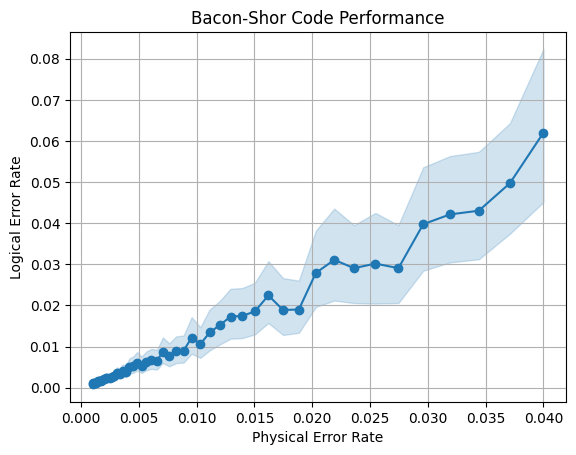

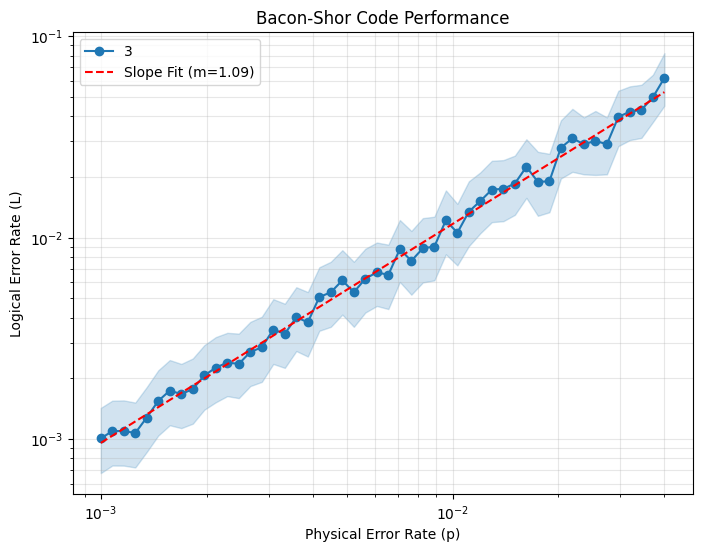

Calculated Slope: 1.0876


In [7]:
ps = np.logspace(np.log10(0.001), np.log10(0.04), 50)
tasks = [
    sinter.Task(
        circuit=bacon_shor_circuit(d=3, p=p),
        json_metadata={'p': p, 'd': 3}
    )
    for p in ps
]

# Run the collection
stats = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=100_000,
    max_errors=100,
)
for stat in stats:
    print(f"p={stat.json_metadata['p']}, errors={stat.errors}, rate={stat.errors/stat.shots}")

fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda stat: stat.json_metadata['p'],
    group_func=lambda stat: stat.json_metadata['d'],
)
ax.set_title("Bacon-Shor Code Performance")
ax.set_xlabel("Physical Error Rate")
ax.set_ylabel("Logical Error Rate")
ax.grid(True)
plt.show()

xs = np.array([s.json_metadata['p'] for s in stats])
ys = np.array([s.errors / s.shots for s in stats])

# Filter out points with 0 errors (log doesn't like zero)
mask = (ys > 0)
log_p = np.log10(xs[mask])
log_L = np.log10(ys[mask])

# Linear regression: log(L) = slope * log(p) + intercept
slope, intercept, r_value, _, _ = linregress(log_p, log_L)

# --- 4. Plotting ---
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Use sinter's plotter for the points
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda s: s.json_metadata['p'],
    group_func=lambda s: s.json_metadata['d'],
)

# Plot the fitted slope line
fit_x = np.linspace(min(xs[mask]), max(xs[mask]), 100)
fit_y = 10**(slope * np.log10(fit_x) + intercept)
ax.plot(fit_x, fit_y, 'r--', label=f'Slope Fit (m={slope:.2f})')

ax.set_title("Bacon-Shor Code Performance")
ax.set_xlabel("Physical Error Rate (p)")
ax.set_ylabel("Logical Error Rate (L)")
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
ax.grid(True, which="both", ls="-", alpha=0.3)
plt.show()

print(f"Calculated Slope: {slope:.4f}")

p=0.001, errors=6, rate=6e-05
p=0.0010781895093053744, errors=9, rate=9e-05
p=0.00125338734534684, errors=12, rate=0.00012
p=0.0011624926179761637, errors=8, rate=8e-05
p=0.001351389086849075, errors=8, rate=8e-05
p=0.001457053536430442, errors=10, rate=0.0001
p=0.0016938139800964523, errors=15, rate=0.00015
p=0.0015709798374755985, errors=17, rate=0.00017
p=0.0018262524640547768, errors=21, rate=0.00021
p=0.0019690462480869506, errors=16, rate=0.00016
p=0.002289001727854742, errors=34, rate=0.00034
p=0.0021230050080244573, errors=22, rate=0.00022
p=0.002467977649754858, errors=38, rate=0.00038
p=0.002660947611165824, errors=44, rate=0.00044
p=0.0028690057991701875, errors=50, rate=0.0005
p=0.0030933319548015776, errors=42, rate=0.00042
p=0.0033351980624661474, errors=68, rate=0.00068
p=0.0038771431271053007, errors=87, rate=0.00087
p=0.004180295045720368, errors=101, rate=0.0010245797701289347
p=0.0035959755624066104, errors=84, rate=0.00084
p=0.005239528910121999, errors=102, rate=0.

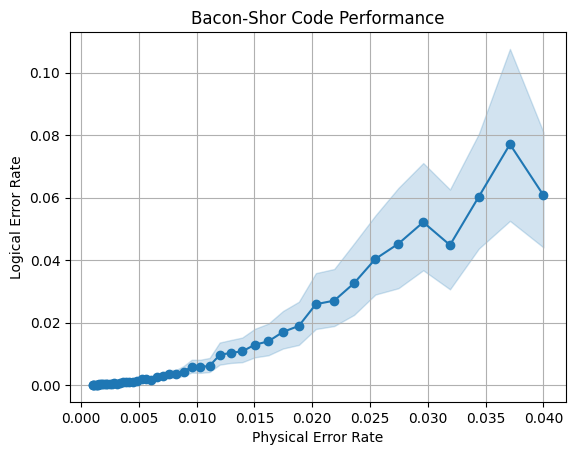

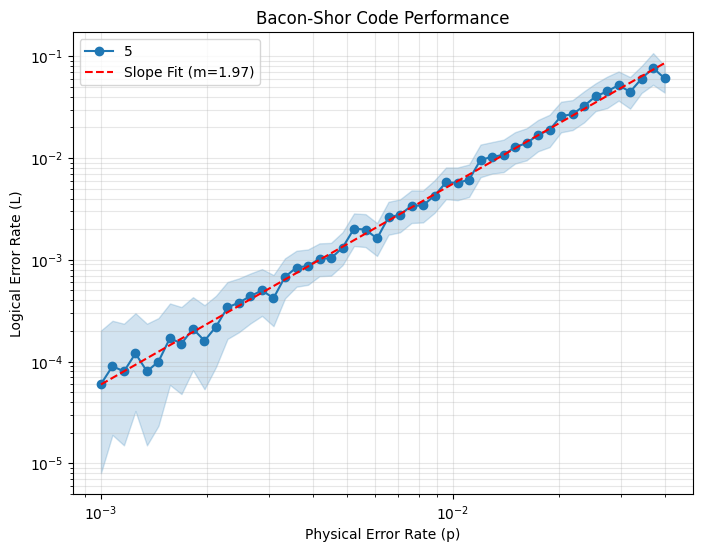

Calculated Slope: 1.9720


In [8]:
ps = np.logspace(np.log10(0.001), np.log10(0.04), 50)
tasks = [
    sinter.Task(
        circuit=bacon_shor_circuit(d=5, p=p),
        json_metadata={'p': p, 'd': 5}
    )
    for p in ps
]

# Run the collection
stats = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=100_000,
    max_errors=100,
)
for stat in stats:
    print(f"p={stat.json_metadata['p']}, errors={stat.errors}, rate={stat.errors/stat.shots}")

fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda stat: stat.json_metadata['p'],
    group_func=lambda stat: stat.json_metadata['d'],
)
ax.set_title("Bacon-Shor Code Performance")
ax.set_xlabel("Physical Error Rate")
ax.set_ylabel("Logical Error Rate")
ax.grid(True)
plt.show()

xs = np.array([s.json_metadata['p'] for s in stats])
ys = np.array([s.errors / s.shots for s in stats])

# Filter out points with 0 errors (log doesn't like zero)
mask = (ys > 0)
log_p = np.log10(xs[mask])
log_L = np.log10(ys[mask])

# Linear regression: log(L) = slope * log(p) + intercept
slope, intercept, r_value, _, _ = linregress(log_p, log_L)

# --- 4. Plotting ---
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Use sinter's plotter for the points
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda s: s.json_metadata['p'],
    group_func=lambda s: s.json_metadata['d'],
)

# Plot the fitted slope line
fit_x = np.linspace(min(xs[mask]), max(xs[mask]), 100)
fit_y = 10**(slope * np.log10(fit_x) + intercept)
ax.plot(fit_x, fit_y, 'r--', label=f'Slope Fit (m={slope:.2f})')

ax.set_title("Bacon-Shor Code Performance")
ax.set_xlabel("Physical Error Rate (p)")
ax.set_ylabel("Logical Error Rate (L)")
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
ax.grid(True, which="both", ls="-", alpha=0.3)
plt.show()

print(f"Calculated Slope: {slope:.4f}")

p=0.001, errors=0, rate=0.0
p=0.0011624926179761637, errors=0, rate=0.0
p=0.00125338734534684, errors=2, rate=2e-05
p=0.0010781895093053744, errors=0, rate=0.0
p=0.0016938139800964523, errors=0, rate=0.0
p=0.001351389086849075, errors=1, rate=1e-05
p=0.001457053536430442, errors=2, rate=2e-05
p=0.0015709798374755985, errors=1, rate=1e-05
p=0.0018262524640547768, errors=0, rate=0.0
p=0.0019690462480869506, errors=2, rate=2e-05
p=0.0021230050080244573, errors=4, rate=4e-05
p=0.002289001727854742, errors=5, rate=5e-05
p=0.002660947611165824, errors=7, rate=7e-05
p=0.002467977649754858, errors=4, rate=4e-05
p=0.0028690057991701875, errors=6, rate=6e-05
p=0.0030933319548015776, errors=9, rate=9e-05
p=0.0035959755624066104, errors=15, rate=0.00015
p=0.0033351980624661474, errors=8, rate=8e-05
p=0.004180295045720368, errors=16, rate=0.00016
p=0.0038771431271053007, errors=10, rate=0.0001
p=0.004507150264096931, errors=20, rate=0.0002
p=0.004859562131612258, errors=34, rate=0.00034
p=0.0056492

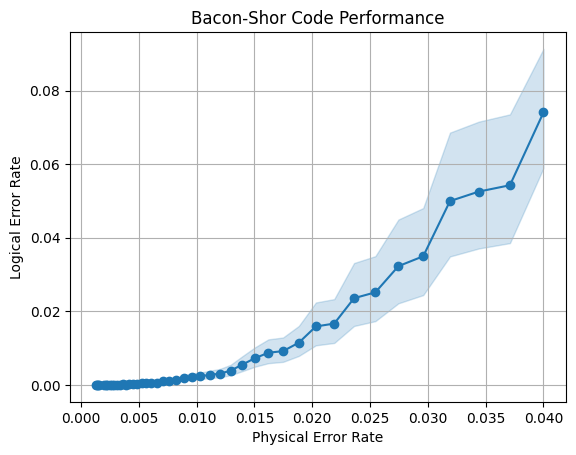

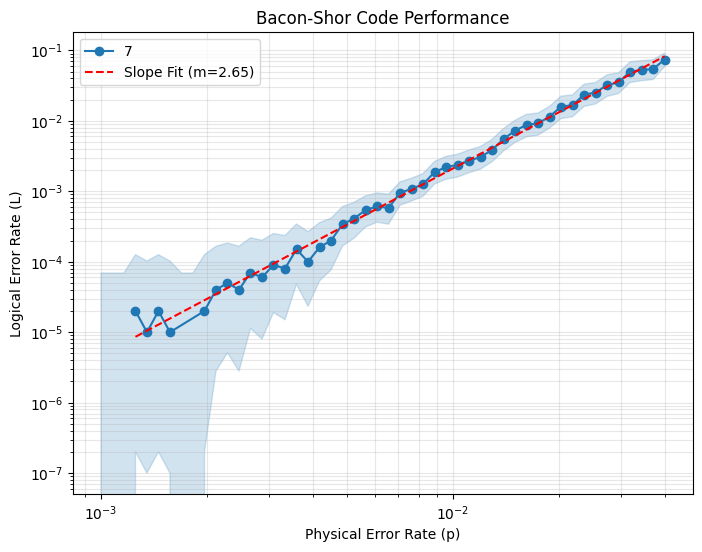

Calculated Slope: 2.6473


In [6]:
ps = np.logspace(np.log10(0.001), np.log10(0.04), 50)
tasks = [
    sinter.Task(
        circuit=bacon_shor_circuit(d=7, p=p),
        json_metadata={'p': p, 'd': 7}
    )
    for p in ps
]

# Run the collection
stats = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=100_000,
    max_errors=100,
)
for stat in stats:
    print(f"p={stat.json_metadata['p']}, errors={stat.errors}, rate={stat.errors/stat.shots}")

fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda stat: stat.json_metadata['p'],
    group_func=lambda stat: stat.json_metadata['d'],
)
ax.set_title("Bacon-Shor Code Performance")
ax.set_xlabel("Physical Error Rate")
ax.set_ylabel("Logical Error Rate")
ax.grid(True)
plt.show()

xs = np.array([s.json_metadata['p'] for s in stats])
ys = np.array([s.errors / s.shots for s in stats])

# Filter out points with 0 errors (log doesn't like zero)
mask = (ys > 0)
log_p = np.log10(xs[mask])
log_L = np.log10(ys[mask])

# Linear regression: log(L) = slope * log(p) + intercept
slope, intercept, r_value, _, _ = linregress(log_p, log_L)

# --- 4. Plotting ---
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Use sinter's plotter for the points
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda s: s.json_metadata['p'],
    group_func=lambda s: s.json_metadata['d'],
)

# Plot the fitted slope line
fit_x = np.linspace(min(xs[mask]), max(xs[mask]), 100)
fit_y = 10**(slope * np.log10(fit_x) + intercept)
ax.plot(fit_x, fit_y, 'r--', label=f'Slope Fit (m={slope:.2f})')

ax.set_title("Bacon-Shor Code Performance")
ax.set_xlabel("Physical Error Rate (p)")
ax.set_ylabel("Logical Error Rate (L)")
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
ax.grid(True, which="both", ls="-", alpha=0.3)
plt.show()

print(f"Calculated Slope: {slope:.4f}")

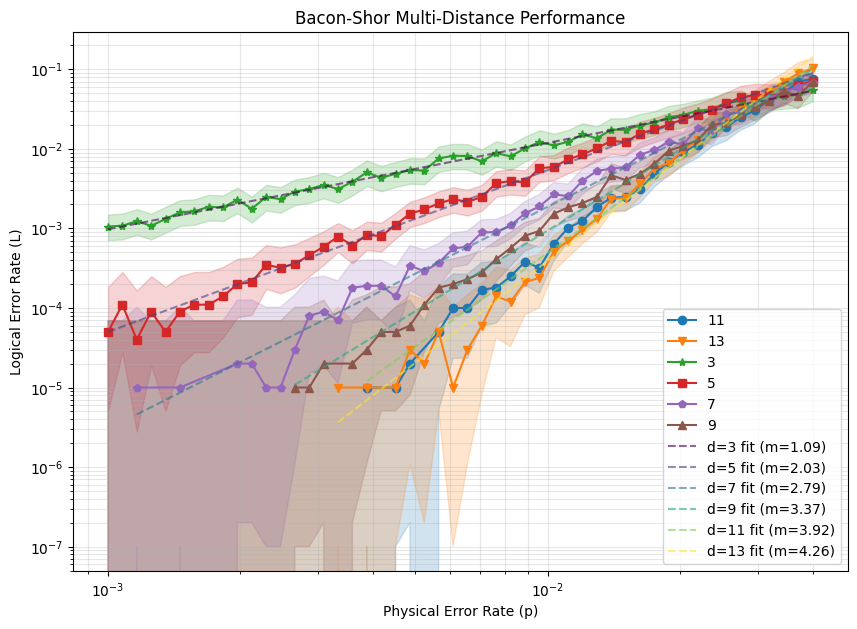

In [11]:
ps = np.logspace(np.log10(0.001), np.log10(0.04), 50)
distances = [3, 5, 7, 9, 11, 13]
tasks = [
    sinter.Task(
        circuit=bacon_shor_circuit(d=d, p=p),
        json_metadata={'p': p, 'd': d}
    )
    for p in ps
    for d in distances
]

# 2. Run the collection
stats = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=100_000,
    max_errors=100,
)

# 3. Plotting with multiple slopes
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Sinter handles the multi-distance scatter plotting automatically
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda s: s.json_metadata['p'],
    group_func=lambda s: s.json_metadata['d'],
)

# 4. Manually add a slope line for each distance
colors = plt.cm.viridis(np.linspace(0, 1, len(distances)))

for i, d in enumerate(distances):
    # Filter stats for this specific distance
    d_stats = [s for s in stats if s.json_metadata['d'] == d]
    xs = np.array([s.json_metadata['p'] for s in d_stats])
    ys = np.array([s.errors / s.shots for s in d_stats])
    
    # Fit logic
    mask = (ys > 0)
    if not any(mask): continue
    
    log_p = np.log10(xs[mask])
    log_L = np.log10(ys[mask])
    slope, intercept, _, _, _ = linregress(log_p, log_L)
    
    # Plot the fit line
    fit_x = np.linspace(min(xs[mask]), max(xs[mask]), 100)
    fit_y = 10**(slope * np.log10(fit_x) + intercept)
    ax.plot(fit_x, fit_y, '--', color=colors[i], alpha=0.6, 
            label=f'd={d} fit (m={slope:.2f})')

ax.set_title("Bacon-Shor Multi-Distance Performance")
ax.set_xlabel("Physical Error Rate (p)")
ax.set_ylabel("Logical Error Rate (L)")
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
ax.grid(True, which="both", ls="-", alpha=0.3)
plt.show()